In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('cr.csv')
df.head()

,Unnamed: 0,Soilcolor,Ph,Potassium,Phosphorus,Nitrogen,Zinc,Sulphur,Humidity-W,Humidity-Sp,...,Precipitation-W,Precipitation-Sp,Precipitation-Su,Precipitation-Au,Wind_Direction_10m_above_ground,Soil_Moisture_in_top_layer,Cloud_cover_percentage_or_amount,Range_of_wind_speed_at_2m_above_ground,Atmospheric_pressure,Crop
0,0,yellowish brown,5.81,738.231,5.401,0.23,2.976000,13.816,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
1,1,yellowish brown,5.43,606.382,10.478,0.23,3.077000,16.421,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
2,2,brown,5.41,386.580,6.847,0.23,6.611000,16.557,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
3,3,red,5.65,207.086,3.418,0.23,0.460181,16.075,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
4,4,red,5.27,317.357,39.282,0.23,2.743000,12.558,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley


In [3]:
df = df.drop(columns=['Unnamed: 0'])

In [4]:
df.isna().sum()

Soilcolor                                 0
Ph                                        0
Potassium                                 0
Phosphorus                                0
Nitrogen                                  0
Zinc                                      0
Sulphur                                   0
Humidity-W                                0
Humidity-Sp                               0
Humidity-Su                               0
Humidity-Au                               0
Air_Temperature_MAX-W                     0
Air_Temperature_MAX-Sp                    0
Air_Temperature_MAX-Su                    0
Air_Temperature_MAX-Au                    0
Air_Temperature_MIN-W                     0
Air_Temperature_MIN-Sp                    0
Air_Temperature_MIN-Su                    0
Air_Temperature_MIN-Au                    0
Precipitation-W                           0
Precipitation-Sp                          0
Precipitation-Su                          0
Precipitation-Au                

In [5]:
df.describe()

,Ph,Potassium,Phosphorus,Nitrogen,Zinc,Sulphur,Humidity-W,Humidity-Sp,Humidity-Su,Humidity-Au,...,Air_Temperature_MIN-Au,Precipitation-W,Precipitation-Sp,Precipitation-Su,Precipitation-Au,Wind_Direction_10m_above_ground,Soil_Moisture_in_top_layer,Cloud_cover_percentage_or_amount,Range_of_wind_speed_at_2m_above_ground,Atmospheric_pressure
count,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,...,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000,3867.000000
mean,5.857295,324.284770,11.349588,0.179153,1.774094,11.311625,8.346870,9.082508,12.232020,10.990747,...,8.934315,1.555862,4.023404,14.517500,4.762687,71.579444,0.709028,51.630709,8.262413,78.426168
std,0.676690,202.250133,34.141864,0.066476,1.460809,5.542094,0.613948,0.790654,0.894970,0.993861,...,2.046221,0.691682,1.117531,4.111199,1.394398,80.929898,0.055355,16.328656,9.661188,2.380380
min,4.300000,41.134000,0.000000,0.000262,0.100000,0.050000,7.183333,7.650000,10.476667,9.070000,...,3.980000,0.000000,1.940000,4.836667,2.156667,0.060000,0.520000,0.460000,4.860000,74.170000
25%,5.390000,191.000000,2.000000,0.131200,1.100000,7.305000,7.933333,8.403333,11.430000,10.150000,...,8.260000,0.910000,3.246667,11.866667,3.463333,36.060000,0.690000,48.620000,5.410000,77.150000
50%,5.780000,282.000000,4.000000,0.179884,1.500000,10.700000,8.383333,9.340000,12.166667,10.926667,...,8.380000,1.736667,4.410000,16.620000,5.430000,68.940000,0.730000,59.110000,6.010000,78.250000
75%,6.200000,405.000000,7.920000,0.230000,2.060000,14.195500,8.910000,9.480000,12.836667,11.433333,...,10.700000,2.073333,5.203333,17.816667,5.823333,88.310000,0.740000,59.110000,6.240000,79.610000
max,8.500000,2119.000000,782.000000,0.695600,45.500000,118.347000,9.723333,10.703333,13.853333,12.800000,...,13.643333,2.780000,5.660000,19.920000,7.420000,354.880000,0.800000,59.110000,46.100000,83.760000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3867 entries, 0 to 3866
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Soilcolor                               3867 non-null   object 
 1   Ph                                      3867 non-null   float64
 2   Potassium                               3867 non-null   float64
 3   Phosphorus                              3867 non-null   float64
 4   Nitrogen                                3867 non-null   float64
 5   Zinc                                    3867 non-null   float64
 6   Sulphur                                 3867 non-null   float64
 7   Humidity-W                              3867 non-null   float64
 8   Humidity-Sp                             3867 non-null   float64
 9   Humidity-Su                             3867 non-null   float64
 10  Humidity-Au                             3867 non-null   floa

In [7]:
df['Soilcolor'].value_counts()

Soilcolor
brown                 1302
red                   1210
black                  868
other                  128
reddish brown          114
gray                    88
dark brown              70
dark gray               38
dark reddish brown      13
very dark brown         11
yellowish brown          7
grayish brown            6
dark grayish brown       4
reddish gray             2
very dark gray           2
light red                1
pearl brown              1
dark red                 1
lightish brown           1
Name: count, dtype: int64

In [8]:
crops_features = df.drop(columns=['Soilcolor','Crop'], axis=1)

In [9]:
# Build statistical outlier detection function

# Separate dataset features for EDA

def detect_outliers(dataset_features):
    """
    Detect outliers in the dataset using the Interquartile Range (IQR) method.
   
    Args:
        dataset_features (pd.DataFrame): Input DataFrame containing numerical features to analyze
       
    Returns:
    pd.DataFrame: DataFrame containing for each feature:
            - Lower Bound: Q1 - 1.5*IQR threshold for outliers
            - Upper Bound: Q3 + 1.5*IQR threshold for outliers 
            - Outliers Count: Number of values outside the bounds      
    Notes:
        - Uses the standard 1.5*IQR rule: points below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are considered outliers
    """
    outliers = pd.DataFrame(index=crops_features.columns)
    # Calculate quantiles
    Q1 = dataset_features.quantile(0.25)
    Q3 = dataset_features.quantile(0.75)
    # Calculate IQR range
    IQR = Q3 - Q1
    # Define upper and lower bounds 
    outliers['Lower Bound'] = Q1 - 1.5*IQR
    outliers['Upper Bound'] = Q3 + 1.5*IQR
    # 
    outliers['Outliers Count'] = [
        ((dataset_features[col] < outliers.loc[col, 'Lower Bound']) | 
         (dataset_features[col] > outliers.loc[col, 'Upper Bound'])).sum()
         for col in dataset_features.columns
    ]
    return outliers

# Print the result of detect_outliers
print("\nOutlier Analysis:")
print(detect_outliers(crops_features), '\n')


Outlier Analysis:
                                        Lower Bound  Upper Bound  \
Ph                                         4.175000     7.415000   
Potassium                               -130.000000   726.000000   
Phosphorus                                -6.880000    16.800000   
Nitrogen                                  -0.017000     0.378200   
Zinc                                      -0.340000     3.500000   
Sulphur                                   -3.030750    24.531250   
Humidity-W                                 6.468333    10.375000   
Humidity-Sp                                6.788333    11.095000   
Humidity-Su                                9.320000    14.946667   
Humidity-Au                                8.225000    13.358333   
Air_Temperature_MAX-W                     20.846667    32.473333   
Air_Temperature_MAX-Sp                    25.440000    34.586667   
Air_Temperature_MAX-Su                    20.368333    28.808333   
Air_Temperature_MAX-Au       

In [10]:
custom_palette = ['#2c5530', '#739e82', '#f3ffb6', '#d38b5d', '#99621e']

%config InlineBackend.figure_format='retina'
custom_params = {'grid.alpha': 0.5, 
                 'axes.titlesize': 12, 
                 #'figure.figsize': (10, 5),
                 'figure.titlesize': 14,
                 'axes.spines.top': False, # Remove the top and right spines
                 'axes.spines.right': False, # Remove the top and right spines
                 'axes.labelsize': 10,
                 'xtick.labelsize': 8,
                 'ytick.labelsize': 8,
                }

sns.set_theme(context='paper', style='whitegrid', palette='BrBG', font='sans-serif', font_scale=1, color_codes=True, 
              rc=custom_params)


In [11]:
# Create correlation matrix
correlation_matrix = df.drop(columns=['Soilcolor','Crop'], axis=1).corr()

# Visualize correlations
fig, axes = plt.subplots(figsize=(50,50), dpi=100)
sns.heatmap(correlation_matrix, annot=True, cmap=custom_palette, center=0)
plt.title('Feature Correlation Matrix')
# Adjust label sizes
plt.xticks(fontsize=8)  # Smaller x-axis labels
plt.yticks(fontsize=8)  # Smaller y-axis labels
plt.title('Feature Correlation Matrix', fontsize=10)  # Smaller title
plt.show()

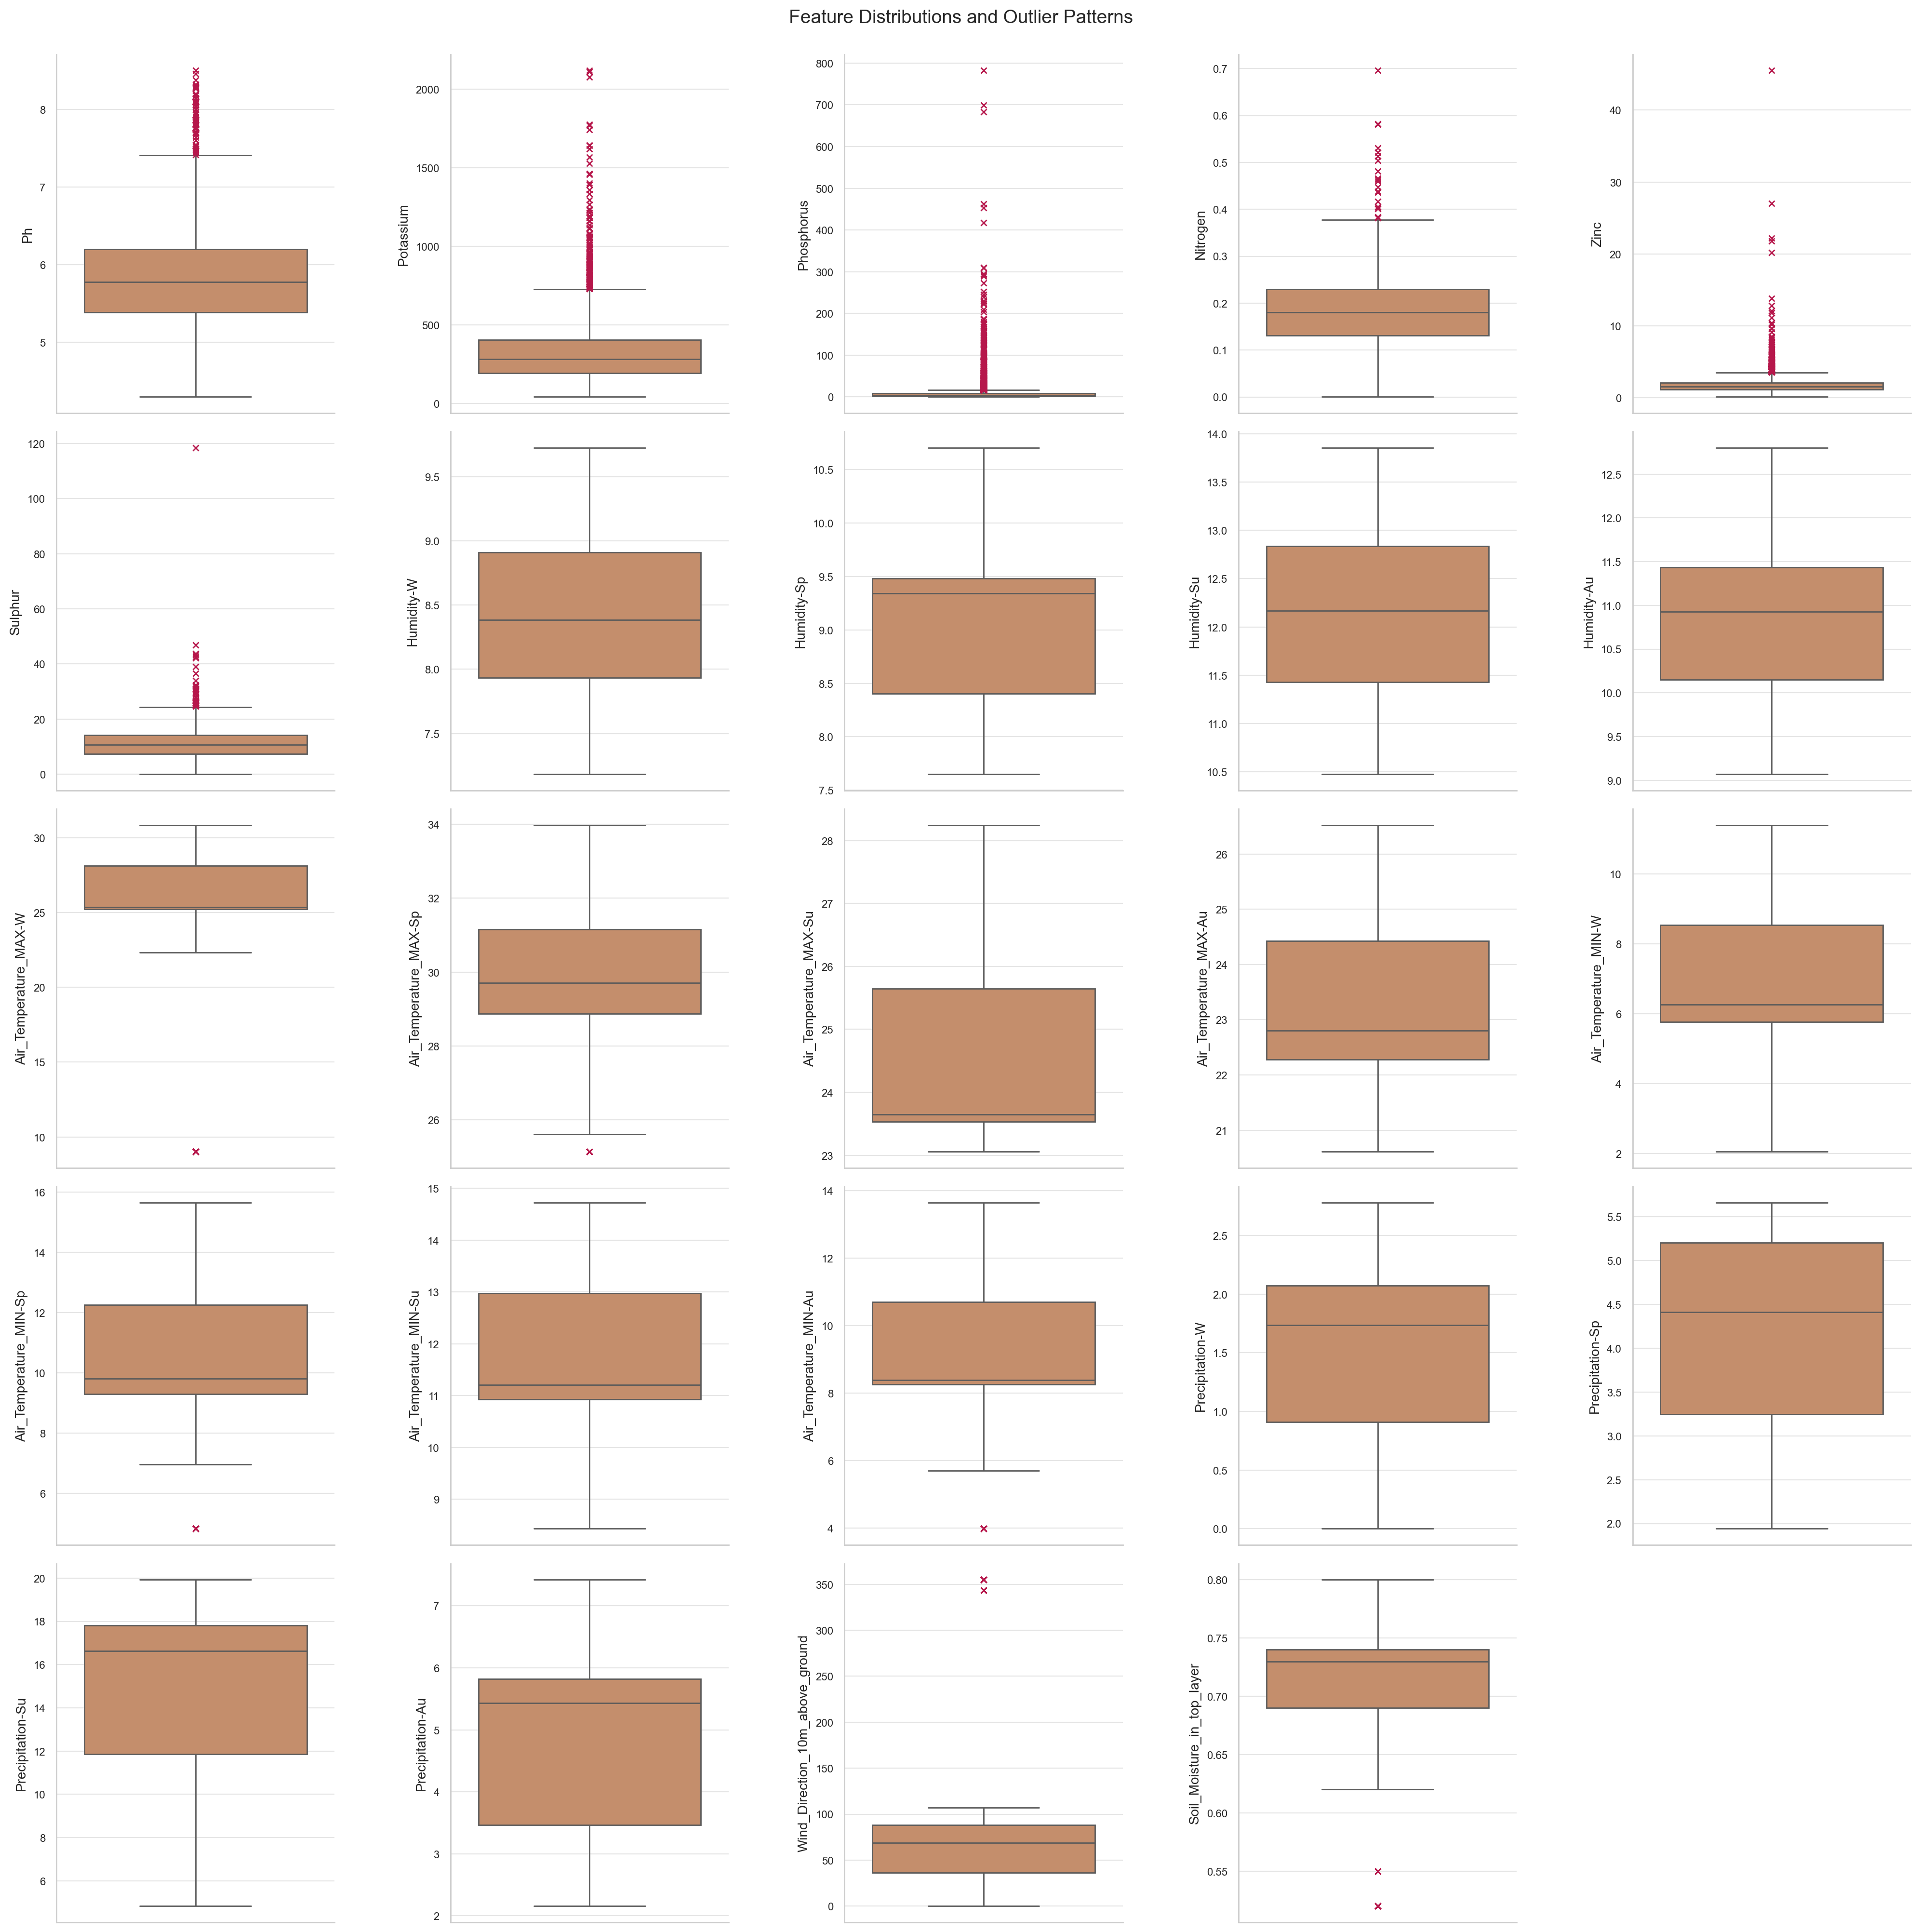

In [12]:
# Visualize distributions
fig, axes = plt.subplots(5, 5, figsize=(20,20))

for ax, col in zip(axes.flat[:len(crops_features.columns)], crops_features.columns): # .flat converts a multi-dimensional array into a 1D array.
    # Create a boxplot
    sns.boxplot(data=crops_features, y=col, ax=ax, color=custom_palette[3], flierprops={'markerfacecolor': '#b6174b', 
                                                                                       'markeredgecolor': '#b6174b', 
                                                                                       'marker': 'x',
                                                                                       'markersize': 4})
axes.flat[-1].remove()
# Add figure title
fig.suptitle('Feature Distributions and Outlier Patterns', y=1)
plt.tight_layout(h_pad=1, w_pad=5)  # Increase spacing between subplots
plt.show()
                 

In [13]:

# # Create a mask to ignore the lower triangle and diagonal of the correlation matrix
# upper_triangle = correlation_matrix.where(
#     np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
# )

# # Find features with a correlation greater than 0.9
# to_drop = [
#     column for column in upper_triangle.columns 
#     if any(upper_triangle[column] > 0.8)
# ]

# # Drop highly correlated columns
# df_reduced = df.drop(columns=to_drop)

# # Print the dropped columns and the resulting dataset
# print("Dropped columns:", to_drop)
# print("Reduced DataFrame shape:", df_reduced.shape)


In [14]:
df.columns

Index(['Soilcolor', 'Ph', 'Potassium', 'Phosphorus', 'Nitrogen', 'Zinc',
       'Sulphur', 'Humidity-W', 'Humidity-Sp', 'Humidity-Su', 'Humidity-Au',
       'Air_Temperature_MAX-W', 'Air_Temperature_MAX-Sp',
       'Air_Temperature_MAX-Su', 'Air_Temperature_MAX-Au',
       'Air_Temperature_MIN-W', 'Air_Temperature_MIN-Sp',
       'Air_Temperature_MIN-Su', 'Air_Temperature_MIN-Au', 'Precipitation-W',
       'Precipitation-Sp', 'Precipitation-Su', 'Precipitation-Au',
       'Wind_Direction_10m_above_ground', 'Soil_Moisture_in_top_layer',
       'Cloud_cover_percentage_or_amount',
       'Range_of_wind_speed_at_2m_above_ground', 'Atmospheric_pressure',
       'Crop'],
      dtype='object')

In [15]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

label_encoder_soil = LabelEncoder()
label_encoder_label = LabelEncoder()
df['Soilcolor'] = label_encoder_soil.fit_transform(df['Soilcolor'])
df['Crop'] = label_encoder_label.fit_transform(df['Crop'])


In [16]:
soilcolor_mapping = dict(zip(label_encoder_soil.classes_, range(len(label_encoder_soil.classes_))))
print("Label to encoded value mapping:", soilcolor_mapping)

Label to encoded value mapping: {'black': 0, 'brown': 1, 'dark brown': 2, 'dark gray': 3, 'dark grayish brown': 4, 'dark red': 5, 'dark reddish brown': 6, 'gray': 7, 'grayish brown': 8, 'light red': 9, 'lightish brown': 10, 'other': 11, 'pearl brown': 12, 'red': 13, 'reddish brown': 14, 'reddish gray': 15, 'very dark brown': 16, 'very dark gray': 17, 'yellowish brown': 18}


In [17]:
label_mapping = dict(zip(label_encoder_label.classes_, range(len(label_encoder_label.classes_))))
print("Label to encoded value mapping:", label_mapping)

Label to encoded value mapping: {'Barley': 0, 'Bean': 1, 'Dagussa': 2, 'Fallow': 3, 'Maize': 4, 'Niger seed': 5, 'Pea': 6, 'Potato': 7, 'Red Pepper': 8, 'Sorghum': 9, 'Teff': 10, 'Wheat': 11}


In [18]:
df.shape

(3867, 29)

In [19]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop(columns=["Crop",], axis=1)
y = df["Crop"]

In [20]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
# X_test = sc.fit_transform(X_test)

In [21]:


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting datasets
print('Shape of X_train:', X_train.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_test:', y_test.shape)


Shape of X_train: (3093, 28)
Shape of y_train: (3093,)
Shape of X_test: (774, 28)
Shape of y_test: (774,)


In [22]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [23]:
def evaluate_model(model, X_test, y_test):
    # Predicting using the provided model
    y_pred = model.predict(X_test)
    
    # Calculating accuracy
    score = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy on Test Data = {score*100:.2f}%")
    
    # Printing classification report
    print(f"Classification Report {model} :\n{classification_report(y_test, y_pred)}")
    
    # Calculating and printing confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cf_matrix}")
    
    # Plotting the confusion matrix
    fig, ax = plt.subplots(figsize=(6,6))
    sns.heatmap(cf_matrix, annot=True, cmap='coolwarm')
    fig.suptitle("Confusion Matrix", color="orange", fontsize=16)
    ax.set(xlabel="Predicted Label", ylabel="Actual Label")
    plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_predrandom = clf.predict(X_test)

# Evaluating the model
score = accuracy_score(y_test, y_predrandom)
print(f"Model Accuracy on Test Data = {score*100:2f}%")

Model Accuracy on Test Data = 52.196382%


Model Accuracy on Test Data = 52.20%
Classification Report RandomForestClassifier(random_state=42) :
              precision    recall  f1-score   support

           0       0.59      0.36      0.45       121
           1       0.28      0.12      0.17        41
           2       0.00      0.00      0.00        15
           3       0.00      0.00      0.00         3
           4       0.51      0.64      0.57       141
           5       0.00      0.00      0.00        15
           6       0.50      0.20      0.29        15
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00        14
          10       0.58      0.78      0.66       254
          11       0.45      0.46      0.45       140

    accuracy                           0.52       774
   macro avg       0.24      0.21      0.22       774
weighted avg       0.48      0.52      0.49       774

Confusion Matrix:
[[ 44   2   0 

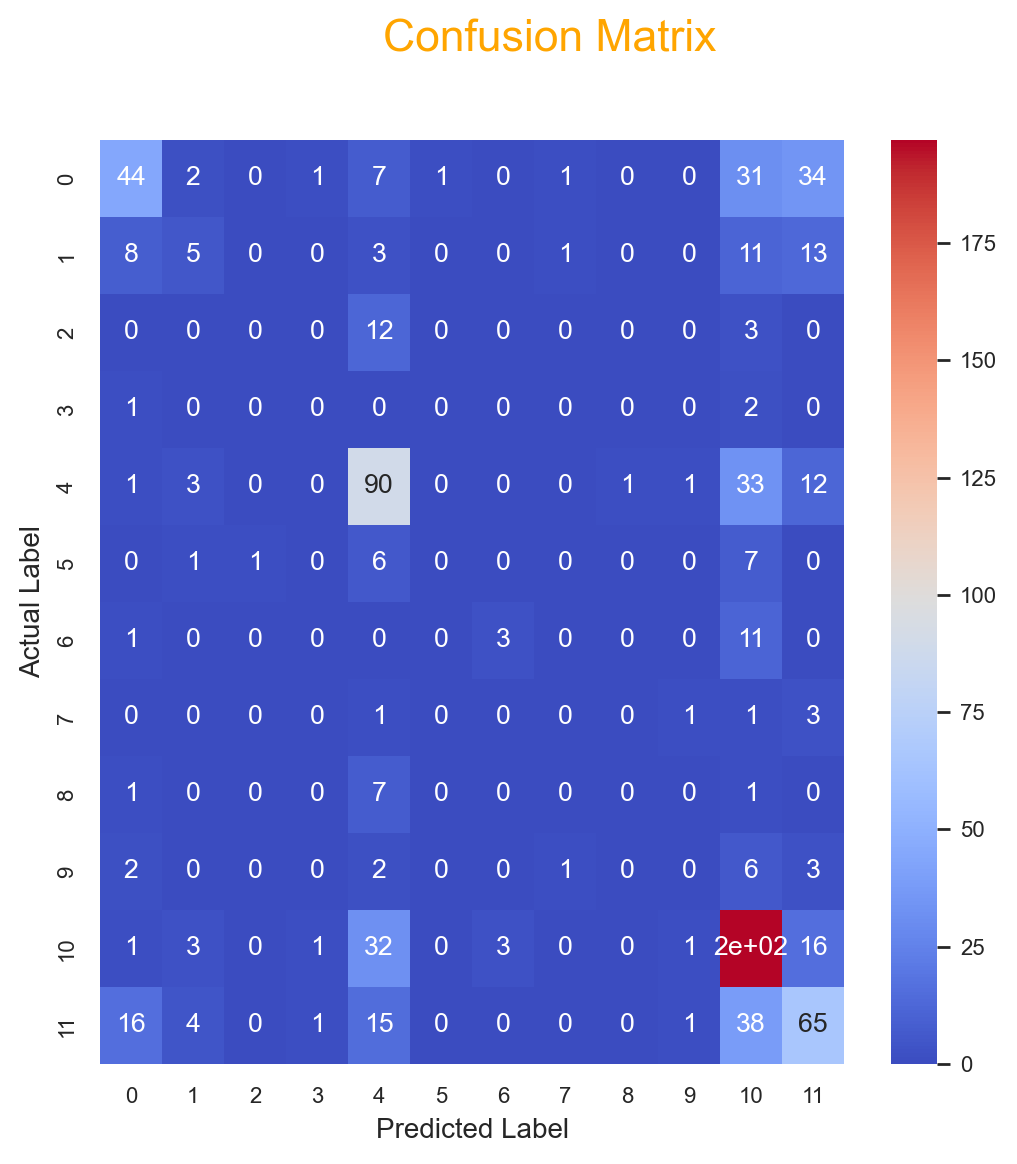

In [25]:
evaluate_model(clf,X_test,y_test)

In [26]:
!pip3 install xgboost

In [27]:
from sklearn.linear_model import LogisticRegression 

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


In [28]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_predxgb = xgb.predict(X_test)
score = accuracy_score(y_test, y_predxgb)
print(f"Model Accuracy on Test Data = {score*100:2f}%")

Model Accuracy on Test Data = 53.100775%


Model Accuracy on Test Data = 53.10%
Classification Report XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...) :
              precision    recall  f1-score   support

           0       0.60      0.40      0.48       121
           1       0.30      0.17      0.22        41
         

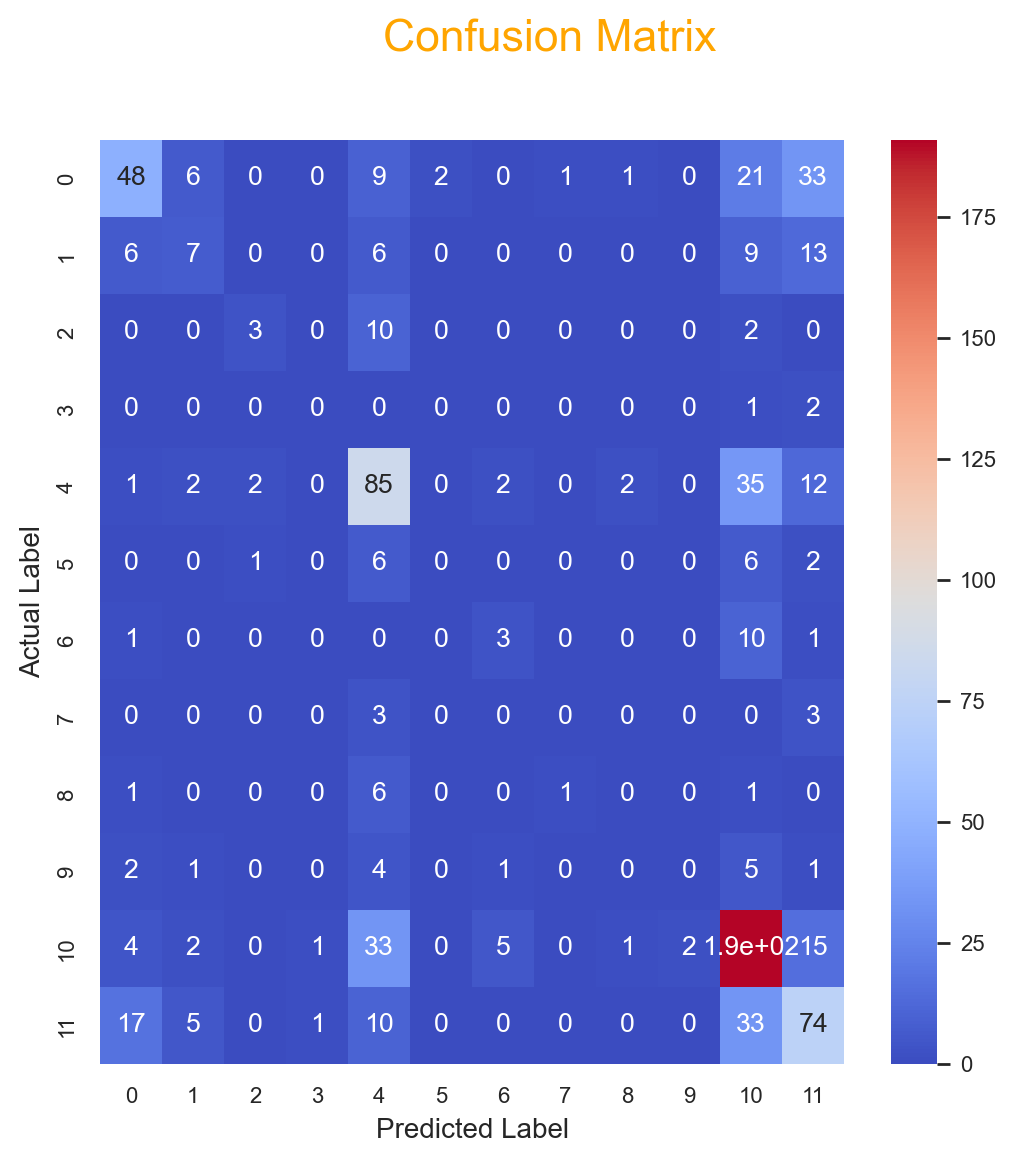

In [29]:
evaluate_model(xgb ,X_test, y_test)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train)
y_predKNN = KNN.predict(X_test)
score = accuracy_score(y_test, y_predKNN)
print(f"Model Accuracy on Test Data = {score*100:2f}%")

Model Accuracy on Test Data = 48.320413%


Model Accuracy on Test Data = 48.32%
Classification Report KNeighborsClassifier() :
              precision    recall  f1-score   support

           0       0.48      0.43      0.45       121
           1       0.10      0.10      0.10        41
           2       0.00      0.00      0.00        15
           3       0.00      0.00      0.00         3
           4       0.47      0.63      0.54       141
           5       0.00      0.00      0.00        15
           6       0.30      0.20      0.24        15
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00         9
           9       0.33      0.07      0.12        14
          10       0.59      0.67      0.63       254
          11       0.46      0.39      0.42       140

    accuracy                           0.48       774
   macro avg       0.23      0.21      0.21       774
weighted avg       0.45      0.48      0.46       774

Confusion Matrix:
[[ 52   9   0   0  12   0   1  

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


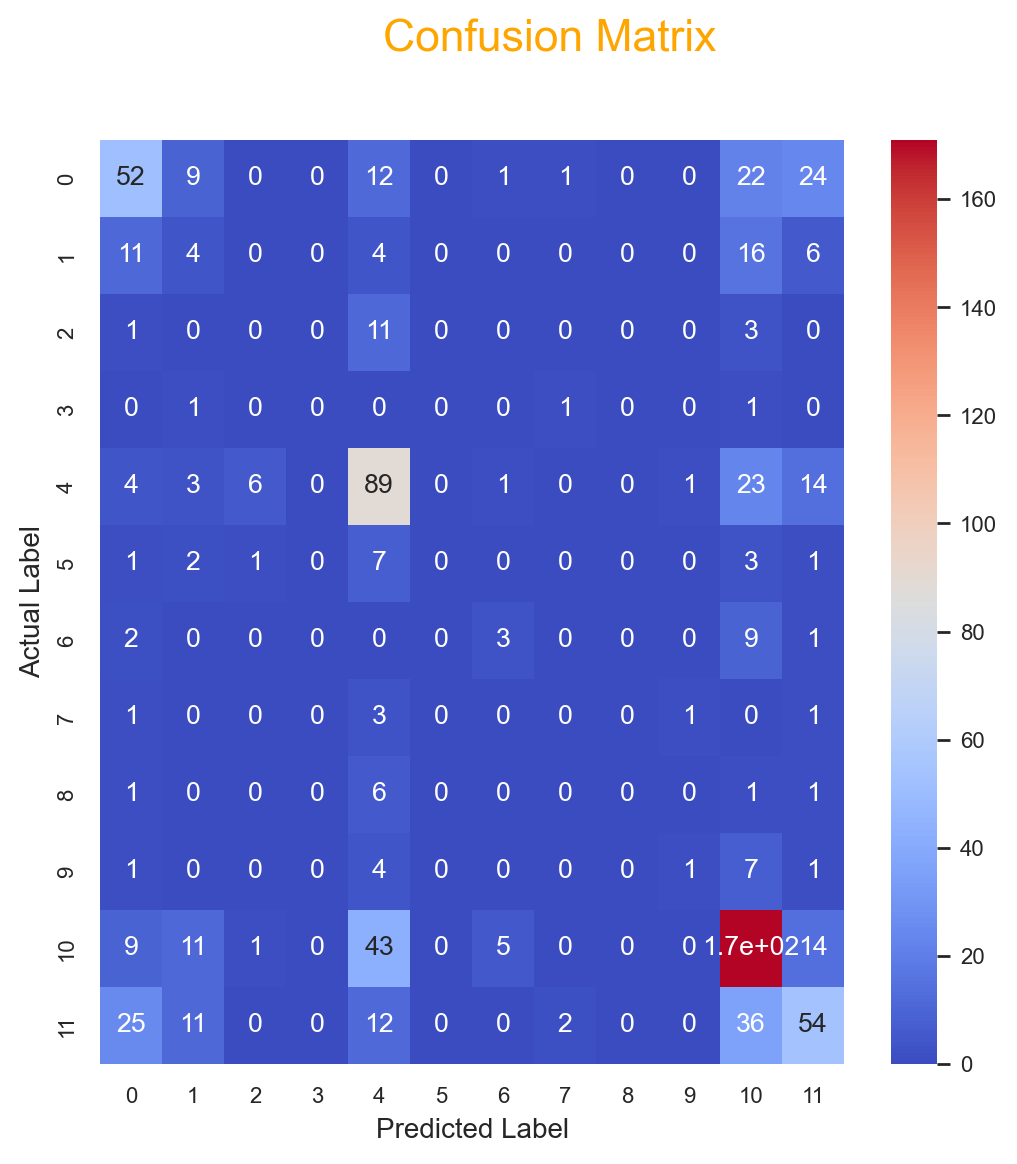

In [31]:
evaluate_model(KNN, X_test, y_test)